## 📌 Project Objective

Build a KNN regression model to diagnose the severity of breast cancer affected by multiple features and this project would include,
- Data overview and analysis using EDA
- EDA charts and key insights
- KNN regression model
- Model evaluation
- Overview of the project through key business and learning insights

### Import required libraries

In [1]:
# EDA libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Model library
from sklearn.neighbors import KNeighborsClassifier

# Model evaluation libraries
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

### Load the dataset

In [4]:
df = pd.read_csv("brca.csv")

### Dataset overview and EDA

#### Dataset info

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   x.radius_mean        569 non-null    float64
 1   x.texture_mean       569 non-null    float64
 2   x.perimeter_mean     569 non-null    float64
 3   x.area_mean          569 non-null    float64
 4   x.smoothness_mean    569 non-null    float64
 5   x.compactness_mean   569 non-null    float64
 6   x.concavity_mean     569 non-null    float64
 7   x.concave_pts_mean   569 non-null    float64
 8   x.symmetry_mean      569 non-null    float64
 9   x.fractal_dim_mean   569 non-null    float64
 10  x.radius_se          569 non-null    float64
 11  x.texture_se         569 non-null    float64
 12  x.perimeter_se       569 non-null    float64
 13  x.area_se            569 non-null    float64
 14  x.smoothness_se      569 non-null    float64
 15  x.compactness_se     569 non-null    flo

#### Target distribution

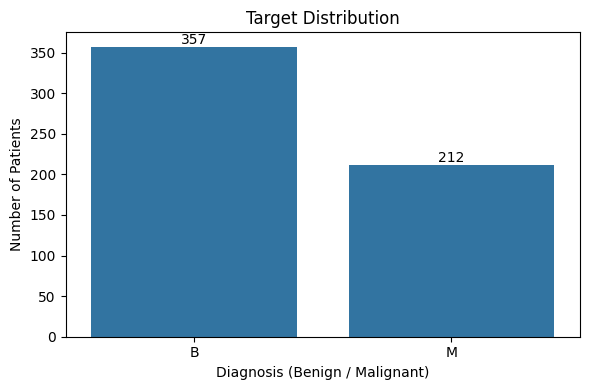

In [9]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x='y', data=df)

# add counts on bars
for container in ax.containers:
    ax.bar_label(container)

plt.xlabel("Diagnosis (Benign / Malignant)")
plt.ylabel("Number of Patients")
plt.title("Target Distribution")
plt.tight_layout()  
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Sitaram_Github\AI_ML_projects\07_KNN_breast_cancer_diagnostic\images\target_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### Insights

- Dataset is imbalanced
- Benign cases >> Malignant cases
- Accuracy alone is misleading → need precision/recall

#### Feature distribution

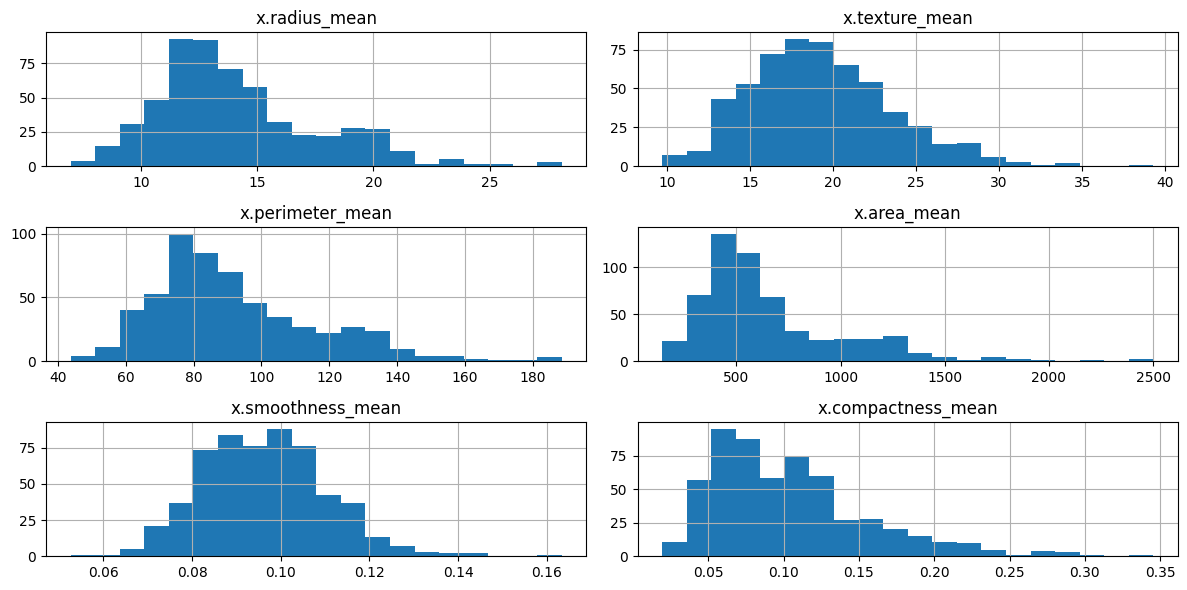

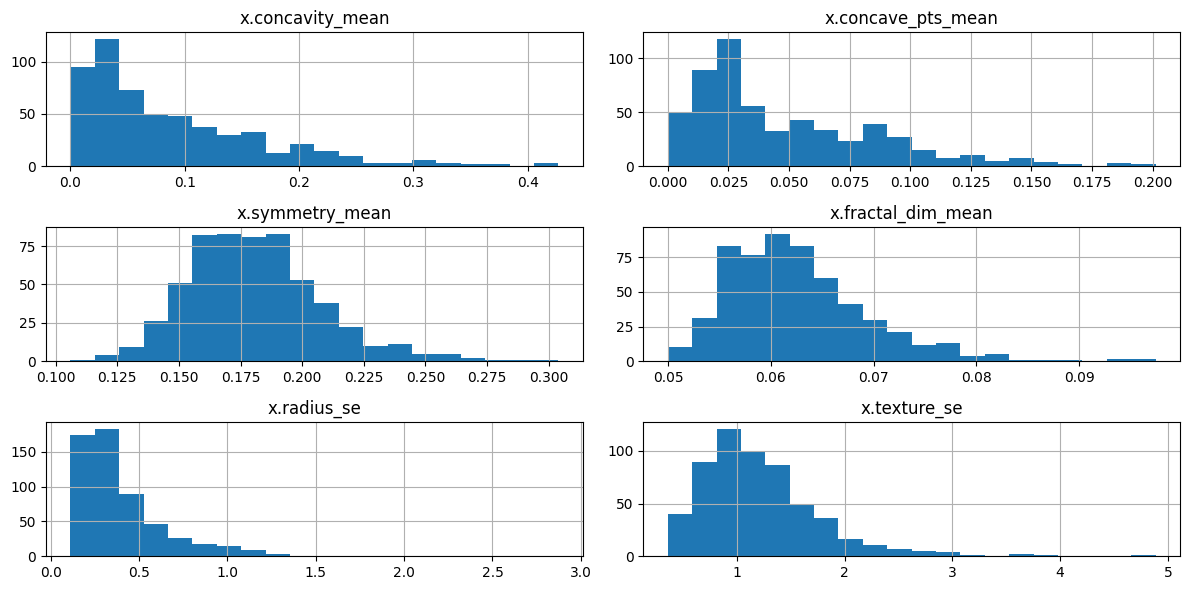

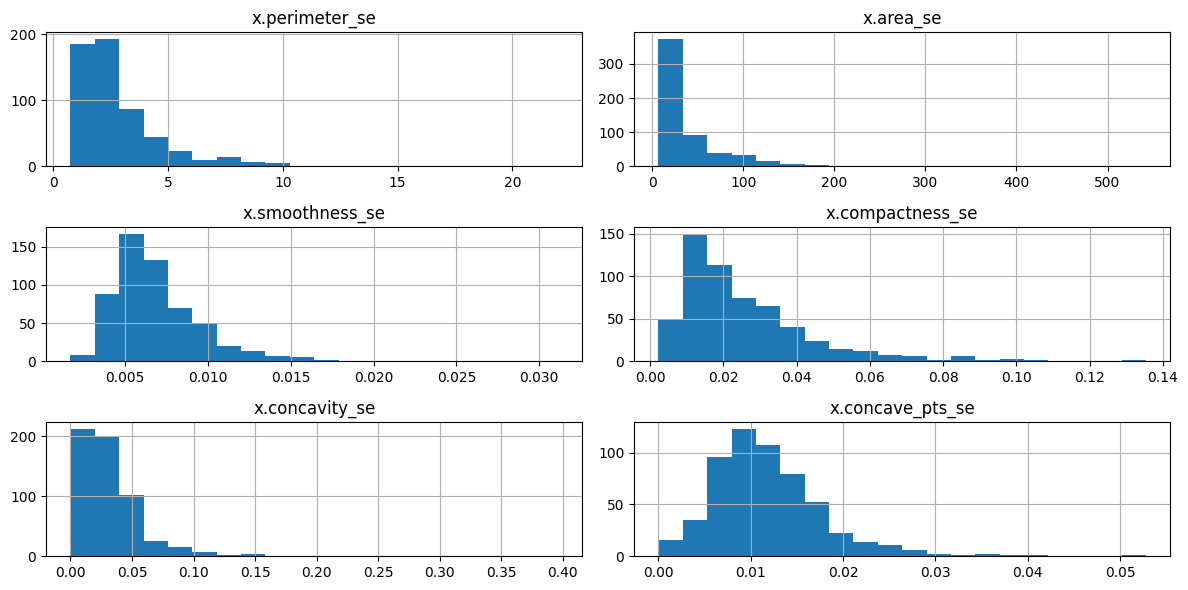

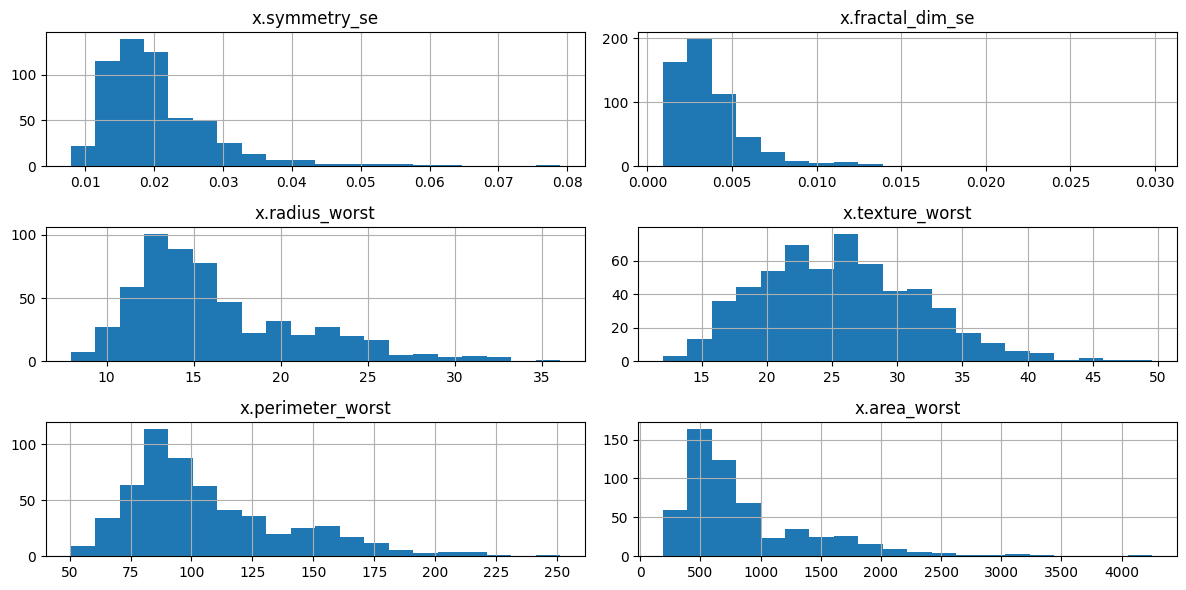

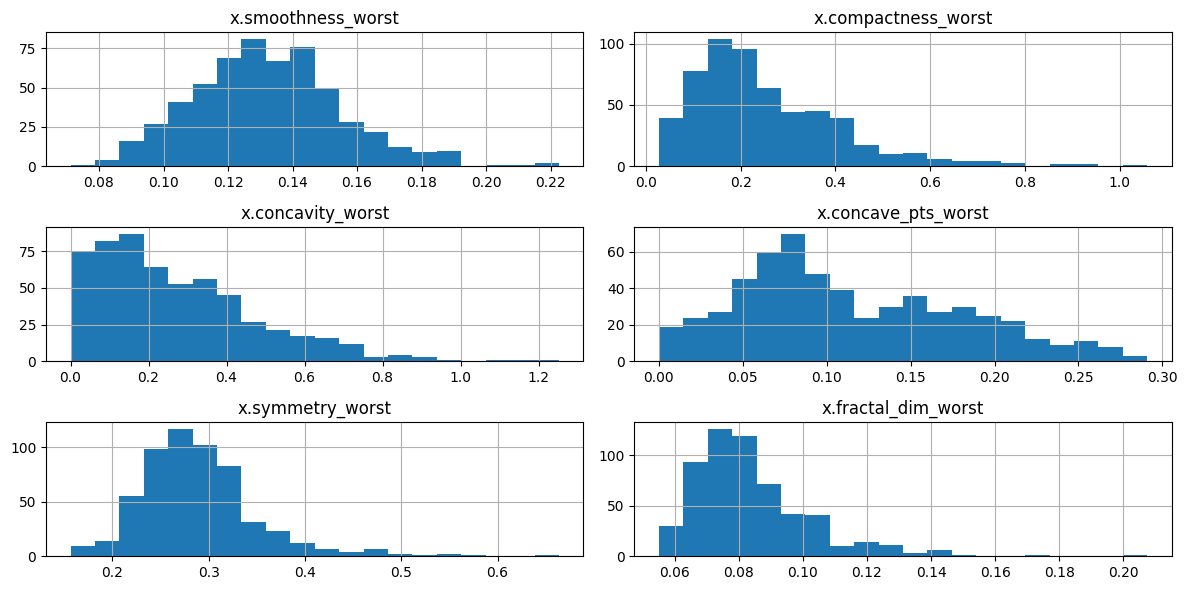

In [18]:
features = df.drop(columns='y').columns

for i in range(0, len(features), 6):
    df[features[i:i+6]].hist(figsize=(12,6), bins=20)
    plt.tight_layout()
    plt.show()

#### Insights

- Many features are right-skewed
- Some features contain clear outliers
- Feature scales are very different → scaling required for KNN
- Certain features show clear separation patterns → useful predictors

#### Correlation heatmap

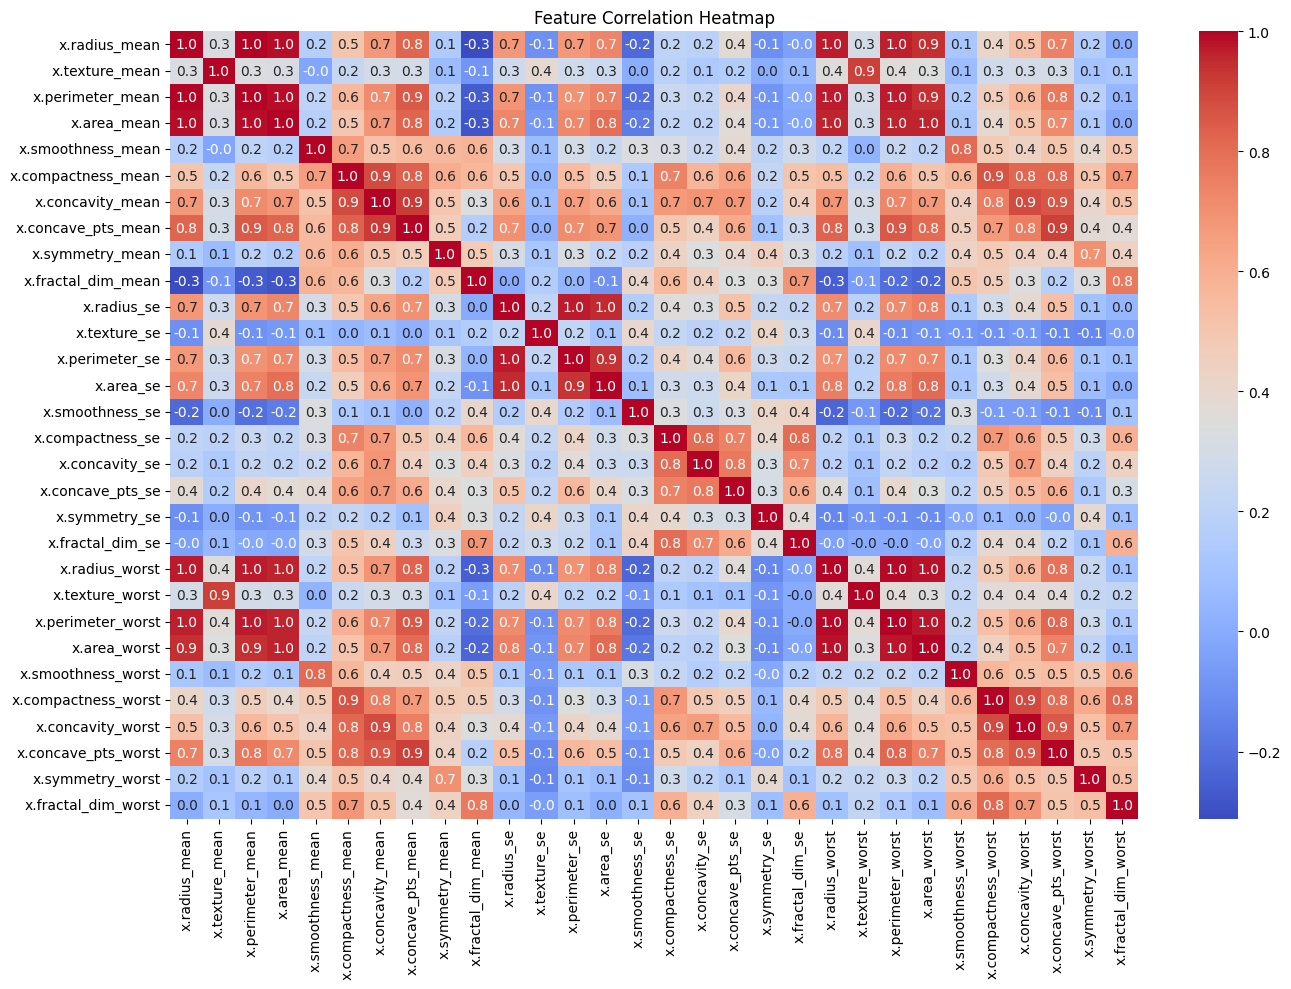

In [15]:
plt.figure(figsize=(14,10))
sns.heatmap(df.drop(columns='y').corr(),
            annot=True,
            fmt=".1f",
            cmap='coolwarm')

plt.title("Feature Correlation Heatmap")
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Sitaram_Github\AI_ML_projects\07_KNN_breast_cancer_diagnostic\images\correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

#### Insights

- Several features are highly correlated (multicollinearity)
- Some measurements are basically repeated information
- Redundant features may not add learning value
- Important to scale and possibly reduce dimensions (PCA optional)

### Preprocessing

#### Select target and features

In [19]:
X = df.drop(columns = 'y')
y = df['y']

#### Encode target

In [21]:
# Import library
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

#### Train test split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size = 0.2, random_state = 42)

#### Feature scaling

In [26]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

### KNN model

#### Select n_neighbors

In [27]:
from sklearn.model_selection import GridSearchCV

param_grid = {'n_neighbors':range(1,25)}
grid = GridSearchCV(KNeighborsClassifier(),param_grid,cv=5)
grid.fit(X_train,y_train)

print(grid.best_params_)

{'n_neighbors': 5}


In [30]:
model = KNeighborsClassifier(
        n_neighbors = 5,
        metric = 'euclidean',
        weights = 'distance'
        )

In [31]:
model.fit(X_train,y_train)

KNeighborsClassifier(metric='euclidean', weights='distance')

In [32]:
y_pred = model.predict(X_test)

### Model evaluation

In [37]:
print("Accuracy score: ", accuracy_score(y_test,y_pred))
print("Confusion matrix: \n",confusion_matrix(y_test,y_pred))
print("Classification report: \n",classification_report(y_test,y_pred))

Accuracy score:  0.9298245614035088
Confusion matrix: 
 [[70  1]
 [ 7 36]]
Classification report: 
               precision    recall  f1-score   support

           0       0.91      0.99      0.95        71
           1       0.97      0.84      0.90        43

    accuracy                           0.93       114
   macro avg       0.94      0.91      0.92       114
weighted avg       0.93      0.93      0.93       114



#### Insights

- **Overall performance is strong** → Accuracy ≈ 93%, model is reliable.
- **Class 0 (Benign) predicted very well**
    - Recall = 0.99 → almost all benign cases correctly identified
    - Very few false alarms
- **Class 1 (Malignant) is the weak area**
    - Recall = 0.84 → model missed 7 cancer cases (False Negatives)
    - This is important because missing cancer is risky.
- **Precision for malignant is high (0.97)**
    - → When model predicts cancer, it is usually correct.
- Main takeaway: Model is accurate but slightly biased toward predicting benign.

## 📌 Key insights and learning summary

### KNN model performance

- Accuracy: 93%
- Weighted F1-score: 0.93
- Macro F1-score: 0.92
- High precision for malignant class (0.97)
- Slightly lower recall for malignant class (0.84) due to missed positive cases

### Model interpretation

- Model predicts benign tumors extremely well (Recall 0.99)
- Main weakness: 7 malignant cases misclassified as benign (False Negatives)
- Model is slightly biased toward predicting benign class
- When the model predicts cancer, it is usually correct (high precision)

### 🧠 Key Analytical Insights

- Dataset is relatively well separable after feature scaling
- Feature scaling (StandardScaler) significantly improves KNN performance
- KNN depends heavily on distance → unscaled features degrade results
- Some features show strong correlation (radius, perimeter, area related features)
- Malignant tumors generally have higher mean radius, texture, and area measurements

### 🏁 Conclusion

KNN provides strong performance for breast cancer detection and is easy to understand.  
However, the model still misses some malignant cases, so improving recall of the malignant class is necessary for a safer medical prediction system.  

### Key business takeaway:
                                                                                                        
Early and accurate tumor classification helps doctors prioritize further tests and treatment.  
Even small improvements in detecting malignant tumors can significantly reduce patient risk, making recall optimization more important than overall accuracy.